In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('primary_input_fs.csv')

print(df.columns)

Index(['A.Age', 'A.Gender', 'A.Education Level', 'A.Monthly Income',
       'A.Marital Status', 'A.Pregnancy Status', 'A.Breastfeeding Status',
       'A.Direct Patient Contact', 'A.Job Type', 'A.Years of Employment',
       'A.COVID-19 Patient Care', 'A.Existing Illnesses', 'A.COVID-19 History',
       'A.Severe was your infection', 'A.Additional Vaccines',
       'A.Immunity Boosters', 'B.Vaccination Status', 'B.Vaccine Choice',
       'B.Vaccine Side Effects', 'B.Family/Friend Side Effects',
       'B.View of vaccine', 'D.Vaccine Protection Perception',
       'D.Side Effect Confidence', 'D.Clinical Trial Confidence',
       'D.Chip Belief', 'D.Mandatory Belief', 'D.Halal Doubt',
       'D.Alternative Medicine Belief', 'A.Blog', 'A.Internet', 'A.KK',
       'A.LamanMS', 'A.Orang', 'A.MediaMassa', 'C.target_mean',
       'A.COVID-19 Risk Perception', 'A.COVID-19 Concern Level', 'B.State',
       'A.Ethnicity', 'A.Religion'],
      dtype='object')


In [2]:
import warnings
import numpy as np

# Suppress overflow warning
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(over='ignore')


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [3]:
import numpy as np

# Apply the threshold to create the hesitant column
df['C.Non_hesitant'] = np.where(df['C.target_mean'] > 2.8, 1, 0)
# Display the resulting DataFrame with the aggregated target and hesitant column
print(df[['C.target_mean', 'C.Non_hesitant']])

     C.target_mean  C.Non_hesitant
0              4.0               1
1              2.4               0
2              4.0               1
3              3.0               1
4              2.1               0
..             ...             ...
549            2.1               0
550            3.0               1
551            3.0               1
552            3.7               1
553            4.0               1

[554 rows x 2 columns]


In [4]:
# Drop the 'C.target_mean' column
df = df.drop(columns=['C.target_mean'])

In [5]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Label Encode the "State" column
state_encoder = LabelEncoder()
df.loc[:, 'B.State'] = state_encoder.fit_transform(df['B.State'])

# Print the label-encoded "State" feature
print(df['B.State'].head())

0    13
1     8
2    12
3    12
4     9
Name: B.State, dtype: object


In [6]:
target=df["C.Non_hesitant"]
features=df.drop('C.Non_hesitant',axis=1)

In [7]:
# Split data into train and test sets

# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset into training + development set and test set
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

In [8]:
# Columns for ANOVA test
anova_columns = [
    'A.Age', 'A.Years of Employment','D.Vaccine Protection Perception', 'D.Side Effect Confidence',
    'D.Clinical Trial Confidence', 'D.Chip Belief', 'D.Mandatory Belief', 'D.Halal Doubt',
    'D.Alternative Medicine Belief'
]

# Columns for Chi-Squared test
chi2_columns = [
    'A.Gender', 'A.Education Level', 'A.Monthly Income', 'A.Marital Status',
    'A.Pregnancy Status', 'A.Breastfeeding Status', 'A.Direct Patient Contact', 'A.Job Type',
    'A.COVID-19 Patient Care', 'A.Existing Illnesses', 'A.COVID-19 History', 'A.Severe was your infection',
    'A.Additional Vaccines', 'A.Immunity Boosters', 'A.COVID-19 Risk Perception', 'A.COVID-19 Concern Level',
    'B.Vaccination Status', 'B.Vaccine Choice', 'B.Vaccine Side Effects', 'B.Family/Friend Side Effects',
    'B.View of vaccine', 'A.Blog', 'A.Internet', 'A.KK', 'A.LamanMS', 'A.MediaMassa',
    'A.Orang', 'B.State', 'A.Ethnicity', 'A.Religion'
]

# Extract and save ANOVA columns from the training set
anova_train = x_train[anova_columns]

# Extract and save Chi-Squared columns from the training set
chi2_train = x_train[chi2_columns]


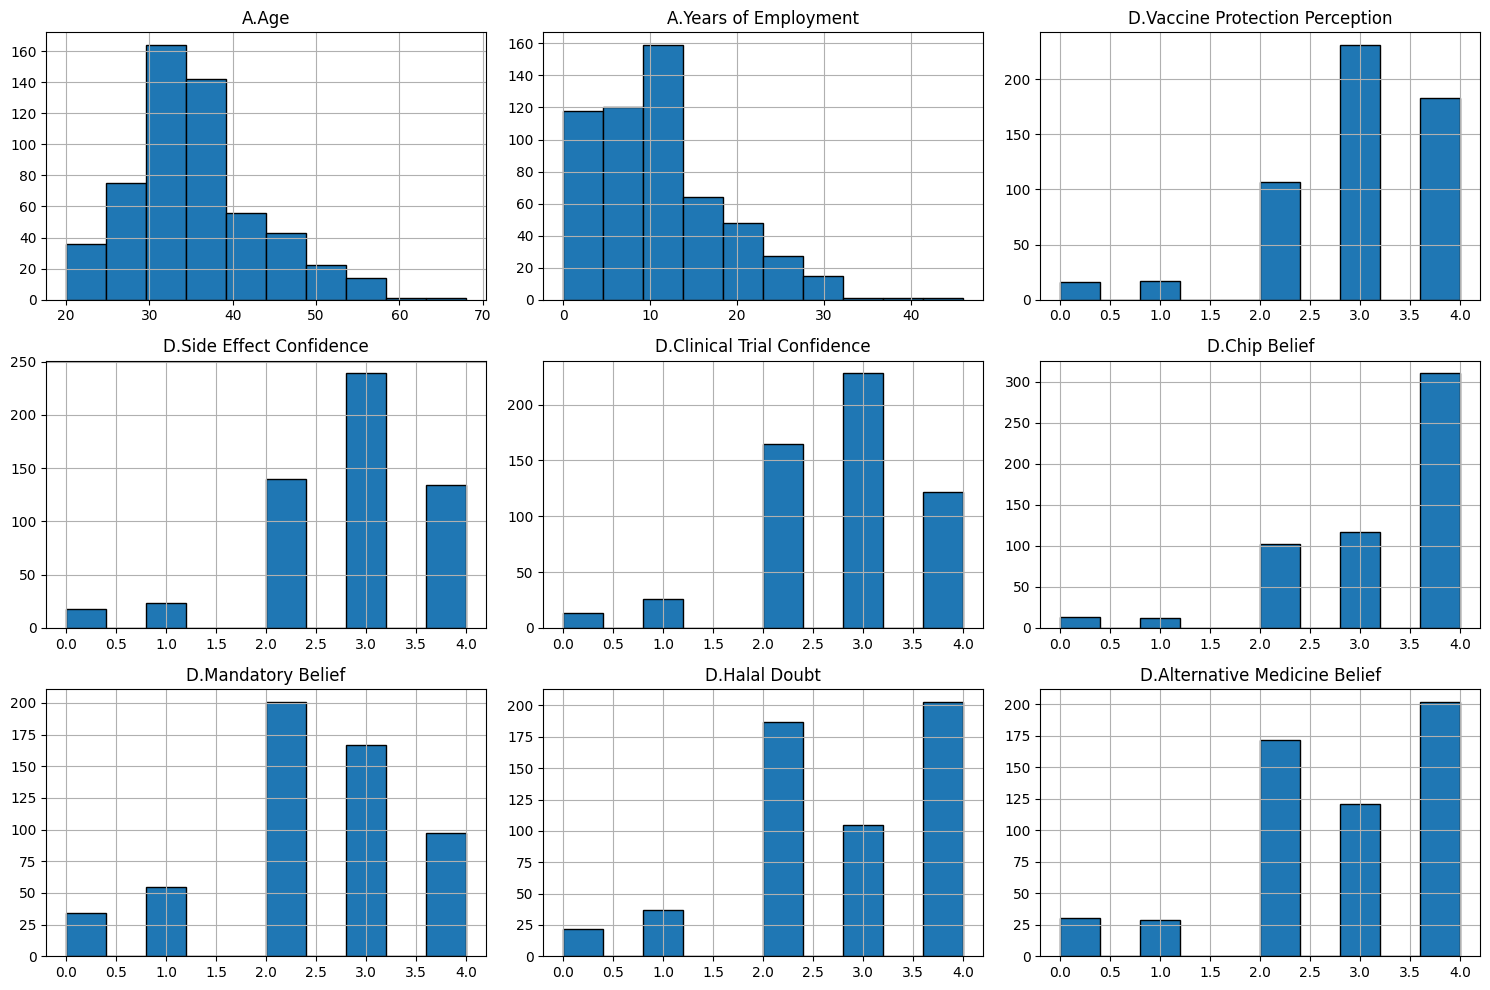

In [12]:
import matplotlib.pyplot as plt

df[anova_columns].hist(
    figsize=(15,10),
    bins=10,
    edgecolor='black'
)

plt.tight_layout()

plt.savefig(
    'anova_histograms_primary.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
from scipy.stats import shapiro

for col in anova_columns:
    stat, p = shapiro(df[col])

    print(f"\n{col}")
    print(f"p-value = {p:.4f}")

    if p > 0.05:
        print("Approximately normal")
    else:
        print("Not normal")


A.Age
p-value = 0.0000
Not normal

A.Years of Employment
p-value = 0.0000
Not normal

D.Vaccine Protection Perception
p-value = 0.0000
Not normal

D.Side Effect Confidence
p-value = 0.0000
Not normal

D.Clinical Trial Confidence
p-value = 0.0000
Not normal

D.Chip Belief
p-value = 0.0000
Not normal

D.Mandatory Belief
p-value = 0.0000
Not normal

D.Halal Doubt
p-value = 0.0000
Not normal

D.Alternative Medicine Belief
p-value = 0.0000
Not normal


# ANOVA TESTING

In [9]:
# Import SelectKBest and chi2 modules
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif


# Apply SelectKBest with ANOVA on the anova_train data
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(anova_train, y_train)
scores = selector.scores_
p_values = selector.pvalues_

# Create a DataFrame to store feature names, scores, and p-values
feature_scores = pd.DataFrame({
    'Feature': anova_train.columns,
    'ANOVA Score': scores,
    'P-value': p_values
})

# Sort the DataFrame by ANOVA scores in descending order
feature_scores_sorted = feature_scores.sort_values(by='ANOVA Score', ascending=False)

# Display the DataFrame
print(feature_scores_sorted)

                           Feature  ANOVA Score       P-value
4      D.Clinical Trial Confidence   349.389954  7.589079e-58
3         D.Side Effect Confidence   260.902814  1.938055e-46
2  D.Vaccine Protection Perception   253.702116  1.899490e-45
6               D.Mandatory Belief   154.188009  1.437076e-30
8    D.Alternative Medicine Belief    52.737444  1.738383e-12
7                    D.Halal Doubt    43.324065  1.319544e-10
5                    D.Chip Belief    39.618188  7.462590e-10
1            A.Years of Employment     0.413693  5.204351e-01
0                            A.Age     0.003264  9.544689e-01


In [10]:
# Select features with p-value < 0.05
significant_features_anova = feature_scores[feature_scores['P-value'] < 0.05]

# Display significant features
print(significant_features_anova)

                           Feature  ANOVA Score       P-value
2  D.Vaccine Protection Perception   253.702116  1.899490e-45
3         D.Side Effect Confidence   260.902814  1.938055e-46
4      D.Clinical Trial Confidence   349.389954  7.589079e-58
5                    D.Chip Belief    39.618188  7.462590e-10
6               D.Mandatory Belief   154.188009  1.437076e-30
7                    D.Halal Doubt    43.324065  1.319544e-10
8    D.Alternative Medicine Belief    52.737444  1.738383e-12


# CHI2 TESTING

In [11]:
# Currently the target is integer data type
y_train.dtype

dtype('int64')

In [12]:
# Import SelectKBest and chi2 modules
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2


# Apply SelectKBest with chi2
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(chi2_train, y_train)
scores = selector.scores_
p_values = selector.pvalues_

# Create a DataFrame to store feature names, scores, and p-values
feature_scores = pd.DataFrame({
    'Feature': chi2_train.columns,
    'Chi-squared Score': scores,
    'P-value': p_values
})

# Sort the DataFrame by Chi-squared scores in descending order
feature_scores_sorted = feature_scores.sort_values(by='Chi-squared Score', ascending=False)

# Display the DataFrame
print(feature_scores_sorted)

                         Feature  Chi-squared Score       P-value
20             B.View of vaccine          78.102735  9.781842e-19
2               A.Monthly Income          16.497914  4.870362e-05
26                       A.Orang          11.994572  5.335572e-04
19  B.Family/Friend Side Effects          10.968880  9.265475e-04
28                   A.Ethnicity           5.623181  1.772445e-02
21                        A.Blog           4.459069  3.471642e-02
13           A.Immunity Boosters           4.176471  4.098897e-02
27                       B.State           3.725856  5.357614e-02
8        A.COVID-19 Patient Care           3.595842  5.792428e-02
16          B.Vaccination Status           2.797565  9.440759e-02
24                     A.LamanMS           2.632523  1.046952e-01
12         A.Additional Vaccines           2.089297  1.483343e-01
29                    A.Religion           1.940813  1.635803e-01
14    A.COVID-19 Risk Perception           1.710826  1.908783e-01
17        

In [13]:
# Select features with p-value < 0.05
significant_features_chi = feature_scores[feature_scores['P-value'] < 0.05]

# Display significant features
print(significant_features_chi)

                         Feature  Chi-squared Score       P-value
2               A.Monthly Income          16.497914  4.870362e-05
13           A.Immunity Boosters           4.176471  4.098897e-02
19  B.Family/Friend Side Effects          10.968880  9.265475e-04
20             B.View of vaccine          78.102735  9.781842e-19
21                        A.Blog           4.459069  3.471642e-02
26                       A.Orang          11.994572  5.335572e-04
28                   A.Ethnicity           5.623181  1.772445e-02


# INFORMATION GAIN 

In [14]:
# Import SelectKBest and information gain modules
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

# Apply SelectKBest with information gain
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(chi2_train, y_train)
scores = selector.scores_ 

# Create a DataFrame to store feature names, scores, and p-values
feature_scores = pd.DataFrame({
    'Feature': chi2_train.columns,
    'Information gain Score': scores,
})

# Sort the DataFrame by Chi-squared scores in descending order
feature_scores_sorted = feature_scores.sort_values(by='Information gain Score', ascending=False)

# Display the DataFrame
print(feature_scores_sorted)

                         Feature  Information gain Score
20             B.View of vaccine                0.084638
18        B.Vaccine Side Effects                0.066105
21                        A.Blog                0.039432
17              B.Vaccine Choice                0.037360
26                       A.Orang                0.035575
0                       A.Gender                0.026425
28                   A.Ethnicity                0.026071
11   A.Severe was your infection                0.025194
1              A.Education Level                0.024299
3               A.Marital Status                0.016193
14    A.COVID-19 Risk Perception                0.013950
19  B.Family/Friend Side Effects                0.012362
29                    A.Religion                0.010344
8        A.COVID-19 Patient Care                0.010127
16          B.Vaccination Status                0.010034
24                     A.LamanMS                0.008943
9           A.Existing Illnesse

In [15]:
selected_features_in = feature_scores_sorted[feature_scores_sorted['Information gain Score'] > 0.05]
print(selected_features_in)

                   Feature  Information gain Score
20       B.View of vaccine                0.084638
18  B.Vaccine Side Effects                0.066105


# COMBINE

In [16]:
result1 = pd.concat([significant_features_anova,significant_features_chi])
result1 = result1.drop(columns=['ANOVA Score', 'P-value', 'Chi-squared Score'])
print (result1)

                            Feature
2   D.Vaccine Protection Perception
3          D.Side Effect Confidence
4       D.Clinical Trial Confidence
5                     D.Chip Belief
6                D.Mandatory Belief
7                     D.Halal Doubt
8     D.Alternative Medicine Belief
2                  A.Monthly Income
13              A.Immunity Boosters
19     B.Family/Friend Side Effects
20                B.View of vaccine
21                           A.Blog
26                          A.Orang
28                      A.Ethnicity


In [18]:
significant_features = result1['Feature'].tolist()
anova_chi = df[significant_features + ['C.Non_hesitant']]
anova_chi.to_csv('anova_chi.csv', index=False)

In [19]:
result2 = pd.concat([significant_features_anova,selected_features_in])
result2 = result2.drop(columns=['ANOVA Score', 'P-value', 'Information gain Score'])
print (result2)

                            Feature
2   D.Vaccine Protection Perception
3          D.Side Effect Confidence
4       D.Clinical Trial Confidence
5                     D.Chip Belief
6                D.Mandatory Belief
7                     D.Halal Doubt
8     D.Alternative Medicine Belief
20                B.View of vaccine
18           B.Vaccine Side Effects


In [20]:
significant_features = result2['Feature'].tolist()
anova_in = df[significant_features + ['C.Non_hesitant']]
anova_in.to_csv('anova_IG.csv', index=False)